<a href="https://colab.research.google.com/github/pranatipradhanwork-alt/Tata_Steel_machine_failure_predict/blob/feature%2Fcolab-notebook/notebooks/tata_steel_machine_failure_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Failure Prediction for Manufacturing Equipment

## Project summary
This project explores whether machine operating measurements can help identify equipment failures and support proactive maintenance. The dataset is synthetic, so results are a learning prototype and would need validation on real plant data.

**GitHub repository:** https://github.com/pranatipradhanwork-alt/Tata_Steel_machine_failure_predict

## Business problem
Unexpected equipment failures can interrupt production and increase maintenance costs. We will assess whether machine readings provide useful warning signals.

## Modeling question
Can the available operational measurements predict `Machine failure`? The training data is strongly imbalanced, so we will evaluate recall, precision, F1-score, and the confusion matrix rather than relying on accuracy alone.

## Notebook sections
1. Load and understand the data
2. Data quality checks and exploratory analysis
3. Target distribution and class imbalance
4. Feature preparation and leakage checks
5. Stratified train/validation split
6. Baseline and model comparison
7. Evaluation and feature importance
8. Conclusions, limitations, and next steps

## Data loading
Upload `train.csv` and `test.csv` to this Colab session when prompted. The raw files will not be added to the public GitHub repository.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from google.colab import files

def latest_csv(prefix):
    matches = list(Path.cwd().glob(f"{prefix}*.csv"))
    return max(matches, key=lambda path: path.stat().st_mtime) if matches else None

# Reuse files already in this Colab runtime. If the runtime was reset, upload them.
train_path = latest_csv("train")
test_path = latest_csv("test")
if train_path is None or test_path is None:
    print("Select train.csv and test.csv in the upload dialog.")
    files.upload()
    train_path = latest_csv("train")
    test_path = latest_csv("test")

if train_path is None or test_path is None:
    raise FileNotFoundError("Could not find both train and test CSV files in the Colab runtime.")

print(f"Using training file: {train_path.name}")
print(f"Using test file: {test_path.name}")
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
print(f"Training data: {train.shape[0]:,} rows × {train.shape[1]} columns")
print(f"Test data: {test.shape[0]:,} rows × {test.shape[1]} columns")
display(train.head())

Using training file: train.csv
Using test file: test (1).csv
Training data: 136,429 rows × 14 columns
Test data: 90,954 rows × 13 columns


,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,0,L50096,L,300.6,309.6,1596,36.1,140,0,0,0,0,0,0
1,1,M20343,M,302.6,312.1,1759,29.1,200,0,0,0,0,0,0
2,2,L49454,L,299.3,308.5,1805,26.5,25,0,0,0,0,0,0
3,3,L53355,L,301.0,310.9,1524,44.3,197,0,0,0,0,0,0
4,4,M24050,M,298.0,309.0,1641,35.4,34,0,0,0,0,0,0


## Dataset overview and data quality

The training file contains 136,429 rows and the test file contains 90,954 rows. The training target is `Machine failure`; it has 2,148 failures (about 1.57%) and 134,281 non-failures. The test file does not include the target, so it will be reserved for predictions after model selection.

Initial checks found no blank cells or duplicate `id` values. The data includes product category and machine readings for air temperature, process temperature, rotational speed, torque, and tool wear. We will verify these checks below.

`TWF`, `HDF`, `PWF`, `OSF`, and `RNF` are failure-mode flags. We will investigate their meaning and exclude them from model inputs unless the project documentation establishes they are known before failure. We will also avoid using row or product identifiers as model features unless there is a clear predictive reason.

Training shape: (136429, 14)
Test shape: (90954, 13)

Column types:


,dtype
id,int64
Product ID,object
Type,object
Air temperature [K],float64
Process temperature [K],float64
Rotational speed [rpm],int64
Torque [Nm],float64
Tool wear [min],int64
Machine failure,int64
TWF,int64



Training data quality summary:


,missing_values,unique_values
id,0,136429
Product ID,0,9976
Type,0,3
Air temperature [K],0,95
Process temperature [K],0,81
Rotational speed [rpm],0,952
Torque [Nm],0,611
Tool wear [min],0,246
Machine failure,0,2
TWF,0,2


Duplicate rows: 0
Duplicate IDs: 0


,count,percent
Machine failure,,
0,134281,98.426
1,2148,1.574


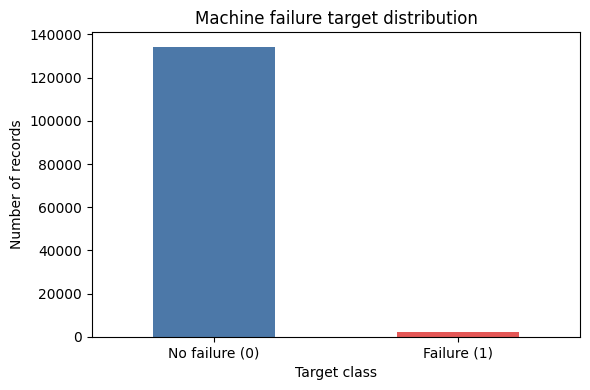

In [5]:
TARGET = "Machine failure"

# Confirm the expected target is present only in the labeled training data.
assert TARGET in train.columns
assert TARGET not in test.columns

print("Training shape:", train.shape)
print("Test shape:", test.shape)
print("\nColumn types:")
display(train.dtypes.rename("dtype").to_frame())

quality = pd.DataFrame({
    "missing_values": train.isna().sum(),
    "unique_values": train.nunique(dropna=False),
})
print("\nTraining data quality summary:")
display(quality)
print("Duplicate rows:", train.duplicated().sum())
print("Duplicate IDs:", train["id"].duplicated().sum())

# Inspect the target distribution and class imbalance.
target_counts = train[TARGET].value_counts().sort_index()
target_summary = pd.DataFrame({
    "count": target_counts,
    "percent": (target_counts / len(train) * 100).round(3),
})
display(target_summary)

ax = target_counts.rename(index={0: "No failure (0)", 1: "Failure (1)"}).plot(
    kind="bar", color=["#4C78A8", "#E45756"], figsize=(6, 4)
)
ax.set_title("Machine failure target distribution")
ax.set_xlabel("Target class")
ax.set_ylabel("Number of records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Exploratory data analysis

EDA helps us understand feature ranges, categories, imbalance, and possible relationships with the target before fitting a model. The charts below are descriptive: they can suggest patterns but cannot establish that a feature causes failure.

We will inspect:
- Machine type and how often failure occurs within each type.
- Distributions of the five operating measurements, comparing failed and non-failed rows.
- Correlations among numeric measurements to identify redundancy that could affect linear-model coefficients.

Because failures are rare, compare **failure rates** across groups as well as raw counts; counts alone can be misleading when group sizes differ.

Sensor summary statistics:


,count,mean,std,min,25%,50%,75%,max
Air temperature [K],136429.0,299.86,1.86,295.3,298.3,300.0,301.2,304.4
Process temperature [K],136429.0,309.94,1.39,305.8,308.7,310.0,310.9,313.8
Rotational speed [rpm],136429.0,1520.33,138.74,1181.0,1432.0,1493.0,1580.0,2886.0
Torque [Nm],136429.0,40.35,8.50,3.8,34.6,40.4,46.1,76.6
Tool wear [min],136429.0,104.41,63.97,0.0,48.0,106.0,159.0,253.0


Failure rate by machine/product type:


,records,failures,failure_rate_pct
Type,,,
H,8923,116,1.30
L,95354,1595,1.67
M,32152,437,1.36


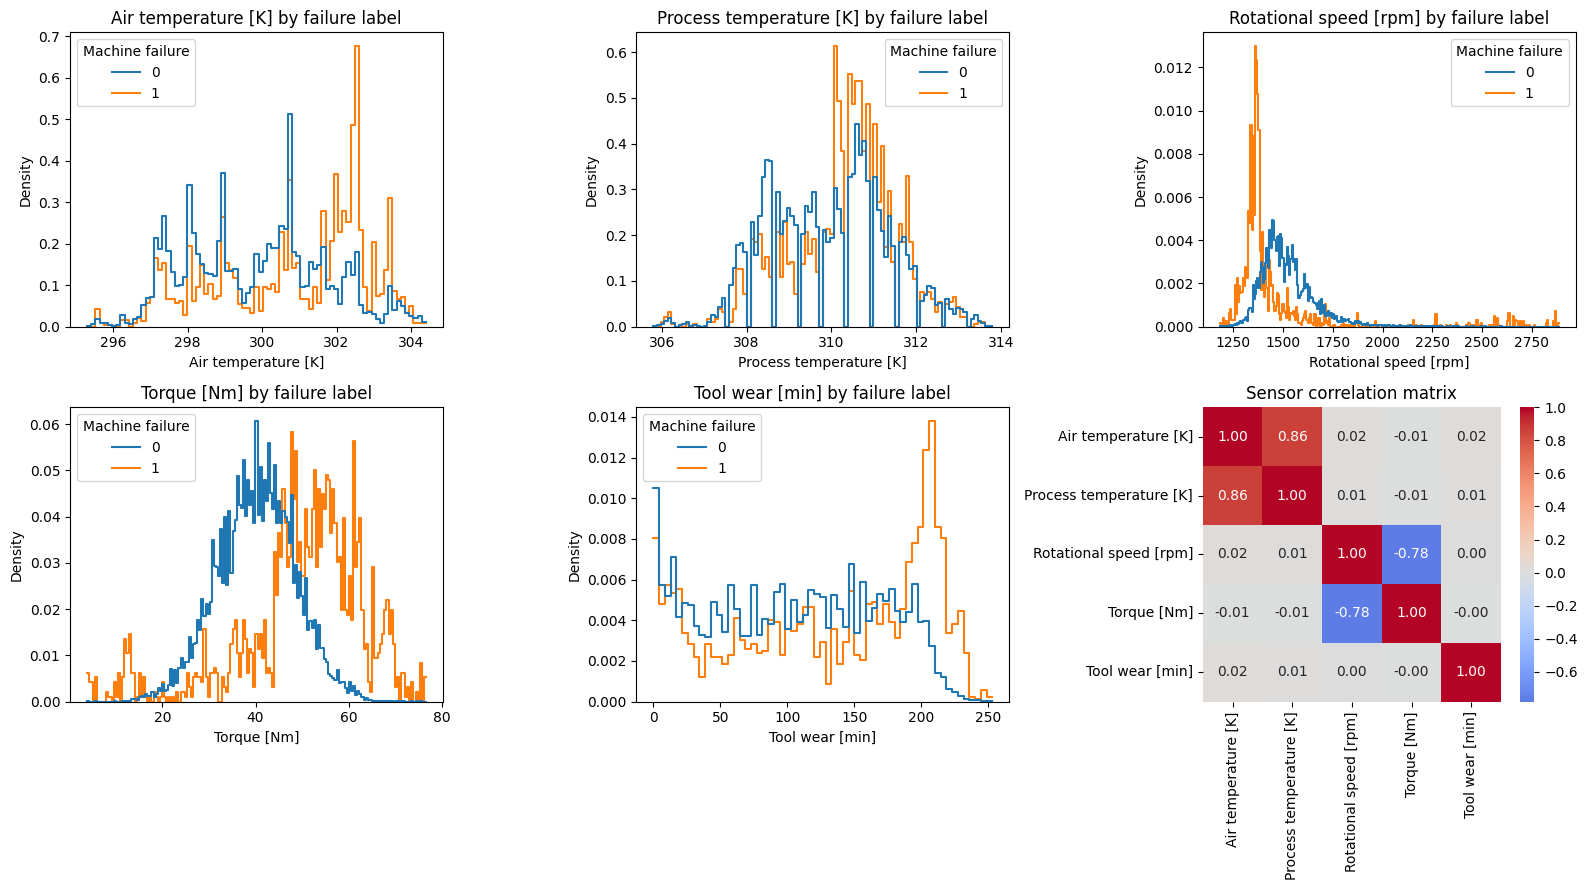

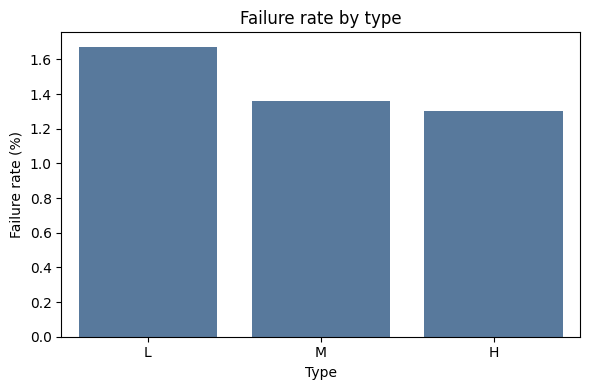

In [6]:
sensor_cols = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
]

print("Sensor summary statistics:")
display(train[sensor_cols].describe().T.round(2))

type_summary = train.groupby("Type")[TARGET].agg(
    records="size", failures="sum", failure_rate="mean"
)
type_summary["failure_rate_pct"] = 100 * type_summary.pop("failure_rate")
print("Failure rate by machine/product type:")
display(type_summary.round(2))

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()
for ax, column in zip(axes[:5], sensor_cols):
    sns.histplot(
        data=train, x=column, hue=TARGET, stat="density", common_norm=False,
        element="step", fill=False, ax=ax
    )
    ax.set_title(f"{column} by failure label")

correlation = train[sensor_cols].corr()
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[5])
axes[5].set_title("Sensor correlation matrix")
plt.tight_layout()
plt.show()

rate_by_type = type_summary["failure_rate_pct"].sort_values(ascending=False)
plt.figure(figsize=(6, 4))
sns.barplot(x=rate_by_type.index, y=rate_by_type.values, color="#4C78A8")
plt.title("Failure rate by type")
plt.xlabel("Type")
plt.ylabel("Failure rate (%)")
plt.tight_layout()
plt.show()

## Feature preparation and leakage checks

The target is `Machine failure` (0 = no failure, 1 = failure). We will keep the five sensor readings and `Type` as inputs. `id` is a row identifier and `Product ID` mostly identifies individual products, so neither is used as a predictor.

The columns `TWF`, `HDF`, `PWF`, `OSF`, and `RNF` describe specific failure modes. These are closely related to the failure event and may not be available before maintenance decisions are made. To avoid giving the model information about the answer, we will inspect how they relate to `Machine failure` and exclude them from the predictors.

For feature creation, we calculate **temperature difference = process temperature − air temperature**. Since this difference is derived from process temperature, we will use air temperature plus the difference, and leave out the original process temperature. This avoids feeding a redundant linear combination to Logistic Regression.

The numeric features will be median-imputed and standardized inside a scikit-learn pipeline; `Type` will be imputed if needed and one-hot encoded. The pipeline is fitted only on the training split, which prevents preprocessing from learning from validation rows. We will use a stratified split to preserve the rare failure rate in both sets.

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

mode_cols = ["TWF", "HDF", "PWF", "OSF", "RNF"]
mode_any = train[mode_cols].eq(1).any(axis=1)
print("How the failure-mode flags overlap the overall target (row-normalized):")
display(pd.crosstab(train[TARGET], mode_any, normalize="index").round(3))
print("Rows where any failure-mode flag differs from Machine failure:", int((train[TARGET] != mode_any.astype(int)).sum()))
print("We exclude these mode flags because they describe failure modes, not pre-failure sensor readings.")

# Check numeric feature correlations. Correlation indicates redundancy, not causation.
corr = train[sensor_cols].corr()
strong_pairs = []
for i, first in enumerate(sensor_cols):
    for second in sensor_cols[i + 1:]:
        value = corr.loc[first, second]
        if abs(value) >= 0.80:
            strong_pairs.append((first, second, round(value, 3)))
print("Sensor pairs with |correlation| >= 0.80:", strong_pairs if strong_pairs else "None")

# Keep Air temperature plus the derived temperature difference; omit Process temperature
# so the feature set does not contain an exact linear combination of all three.
X = train[["Type", "Air temperature [K]", "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"]].copy()
X["Temperature difference [K]"] = train["Process temperature [K]"] - train["Air temperature [K]"]
y = train[TARGET].astype(int)

X_test = test[["Type", "Air temperature [K]", "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"]].copy()
X_test["Temperature difference [K]"] = test["Process temperature [K]"] - test["Air temperature [K]"]

# Split labeled training data; never use the unlabeled test set to tune/evaluate models.
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

numeric_features = [column for column in X.columns if column != "Type"]
categorical_features = ["Type"]
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])

print("Features used:", X.columns.tolist())
print(f"Training split: {len(X_train):,} rows; failures = {y_train.sum():,} ({y_train.mean():.2%})")
print(f"Validation split: {len(X_valid):,} rows; failures = {y_valid.sum():,} ({y_valid.mean():.2%})")
print("Test features shape:", X_test.shape)

How the failure-mode flags overlap the overall target (row-normalized):


col_0,False,True
Machine failure,,
0,0.998,0.002
1,0.236,0.764


Rows where any failure-mode flag differs from Machine failure: 822
We exclude these mode flags because they describe failure modes, not pre-failure sensor readings.
Sensor pairs with |correlation| >= 0.80: [('Air temperature [K]', 'Process temperature [K]', np.float64(0.856))]
Features used: ['Type', 'Air temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Temperature difference [K]']
Training split: 109,143 rows; failures = 1,718 (1.57%)
Validation split: 27,286 rows; failures = 430 (1.58%)
Test features shape: (90954, 6)


## Model training and comparison

We compare three approaches on the same stratified validation split:

- **Dummy baseline:** always predicts the majority class. This shows why accuracy alone can look high even when a model misses every failure.
- **Logistic Regression:** a regularized, interpretable baseline. We use class weights to give rare failures more influence during fitting.
- **Random Forest:** captures nonlinear patterns and feature interactions; balanced subsampling helps address the rare failure class.

The preprocessing and model are kept together in a pipeline, so encoders and scalers are fitted only on training rows. We compare average precision (area under the precision–recall curve) because failure is rare, and also report precision, recall, F1, and accuracy at the default 0.50 probability threshold.

In [8]:
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, f1_score, precision_score, recall_score
)

models = {
    "Majority baseline": Pipeline([
        ("preprocess", preprocessor),
        ("classifier", DummyClassifier(strategy="most_frequent")),
    ]),
    "Logistic Regression": Pipeline([
        ("preprocess", preprocessor),
        ("classifier", LogisticRegression(
            class_weight="balanced", max_iter=1000, random_state=42
        )),
    ]),
    "Random Forest": Pipeline([
        ("preprocess", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            min_samples_leaf=2,
            class_weight="balanced_subsample",
            random_state=42,
            n_jobs=-1,
        )),
    ]),
}

comparison_rows = []
validation_probabilities = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    probabilities = model.predict_proba(X_valid)[:, 1]
    validation_probabilities[name] = probabilities
    predictions_050 = (probabilities >= 0.50).astype(int)
    comparison_rows.append({
        "Model": name,
        "Average precision (AP)": average_precision_score(y_valid, probabilities),
        "Precision @ 0.50": precision_score(y_valid, predictions_050, zero_division=0),
        "Recall @ 0.50": recall_score(y_valid, predictions_050, zero_division=0),
        "F1 @ 0.50": f1_score(y_valid, predictions_050, zero_division=0),
        "Accuracy @ 0.50": accuracy_score(y_valid, predictions_050),
    })

model_comparison = pd.DataFrame(comparison_rows).sort_values(
    "Average precision (AP)", ascending=False
).reset_index(drop=True)
display(model_comparison.round(4))

# Select the model with the strongest validation ranking performance.
best_name = model_comparison.loc[0, "Model"]
best_model = models[best_name]
best_probabilities = validation_probabilities[best_name]
print("Selected model by validation average precision:", best_name)

,Model,Average precision (AP),Precision @ 0.50,Recall @ 0.50,F1 @ 0.50,Accuracy @ 0.50
0,Random Forest,0.4154,0.5663,0.4070,0.4736,0.9857
1,Logistic Regression,0.1536,0.0509,0.7093,0.0950,0.7870
2,Majority baseline,0.0158,0.0000,0.0000,0.0000,0.9842


Selected model by validation average precision: Random Forest


## Evaluation and alert threshold

The default 0.50 cutoff is only a starting point. A maintenance alert may prioritize catching failures, but lowering the cutoff also creates more false alarms. We therefore select a cutoff that maximizes **F2**, a score that weights recall more heavily than precision.

This cutoff is chosen from validation predictions. The validation results are useful for comparing approaches, but a real plant would need a cost-based threshold and testing on future, independently collected data. The confusion matrix makes the trade-off concrete: true failures caught, failures missed, false alarms, and correct non-failure predictions.

Validation metrics at the F2-selected threshold
threshold: 0.2480
precision: 0.4163
recall: 0.6186
f1: 0.4977
f2: 0.5638
accuracy: 0.9803
balanced_accuracy: 0.8024

Confusion matrix [[true non-failures, false alarms], [missed failures, caught failures]]:
[[26483   373]
 [  164   266]]

Class-level report:
              precision    recall  f1-score   support

  No failure       0.99      0.99      0.99     26856
     Failure       0.42      0.62      0.50       430

    accuracy                           0.98     27286
   macro avg       0.71      0.80      0.74     27286
weighted avg       0.98      0.98      0.98     27286



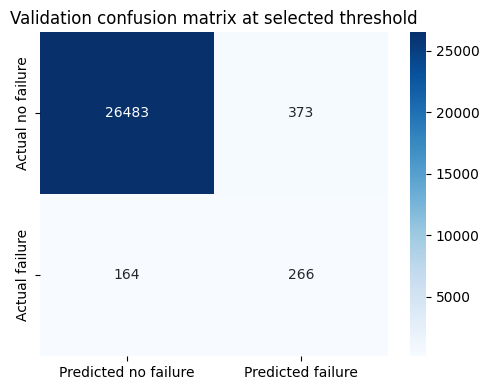

In [9]:
from sklearn.metrics import precision_recall_curve, confusion_matrix, classification_report, balanced_accuracy_score, f1_score, precision_score, recall_score

precision_curve, recall_curve, threshold_values = precision_recall_curve(y_valid, best_probabilities)
f2_values = (5 * precision_curve[:-1] * recall_curve[:-1]) / (4 * precision_curve[:-1] + recall_curve[:-1] + 1e-12)
best_threshold_index = int(np.argmax(f2_values))
selected_threshold = float(threshold_values[best_threshold_index])
y_valid_pred = (best_probabilities >= selected_threshold).astype(int)

threshold_metrics = {
    "threshold": selected_threshold,
    "precision": precision_score(y_valid, y_valid_pred, zero_division=0),
    "recall": recall_score(y_valid, y_valid_pred, zero_division=0),
    "f1": f1_score(y_valid, y_valid_pred, zero_division=0),
    "f2": f2_values[best_threshold_index],
    "accuracy": (y_valid.to_numpy() == y_valid_pred).mean(),
    "balanced_accuracy": balanced_accuracy_score(y_valid, y_valid_pred),
}
print("Validation metrics at the F2-selected threshold")
for metric_name, metric_value in threshold_metrics.items():
    print(f"{metric_name}: {metric_value:.4f}")

cm = confusion_matrix(y_valid, y_valid_pred, labels=[0, 1])
print("\nConfusion matrix [[true non-failures, false alarms], [missed failures, caught failures]]:")
print(cm)
print("\nClass-level report:")
print(classification_report(y_valid, y_valid_pred, target_names=["No failure", "Failure"], zero_division=0))

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Predicted no failure", "Predicted failure"], yticklabels=["Actual no failure", "Actual failure"])
plt.title("Validation confusion matrix at selected threshold")
plt.tight_layout()
plt.show()

,feature,mean_average_precision_drop,std
2,Rotational speed [rpm],0.267540,0.016113
3,Torque [Nm],0.217227,0.034348
5,Temperature difference [K],0.164267,0.034871
4,Tool wear [min],0.159515,0.018789
1,Air temperature [K],0.126846,0.034756
0,Type,0.024529,0.021552


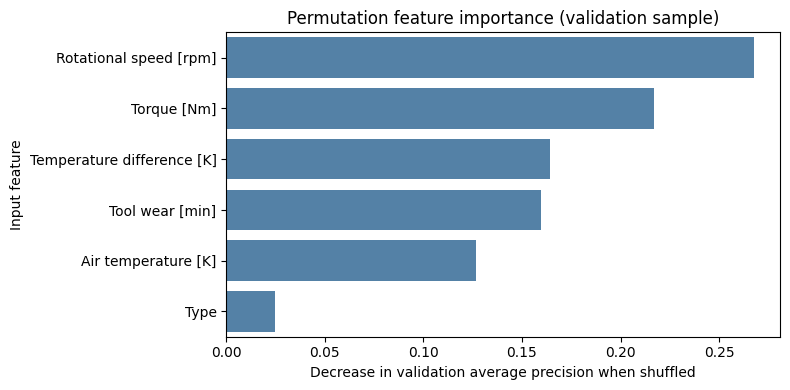

In [10]:
from sklearn.inspection import permutation_importance

# Permute one raw input at a time and measure how much validation average precision falls.
# A 5,000-row sample keeps this computation responsive while preserving the class ratio reasonably well.
X_importance = X_valid.sample(n=min(5000, len(X_valid)), random_state=42)
y_importance = y_valid.loc[X_importance.index]
permutation = permutation_importance(
    best_model,
    X_importance,
    y_importance,
    n_repeats=5,
    random_state=42,
    scoring="average_precision",
    n_jobs=-1,
)
importance_df = pd.DataFrame({
    "feature": X_importance.columns,
    "mean_average_precision_drop": permutation.importances_mean,
    "std": permutation.importances_std,
}).sort_values("mean_average_precision_drop", ascending=False)
display(importance_df)

plt.figure(figsize=(8, 4))
sns.barplot(data=importance_df, x="mean_average_precision_drop", y="feature", color="steelblue")
plt.xlabel("Decrease in validation average precision when shuffled")
plt.ylabel("Input feature")
plt.title("Permutation feature importance (validation sample)")
plt.tight_layout()
plt.show()

### Interpreting feature importance

Permutation importance asks: “How much does validation average precision fall when I shuffle one input column?” Here, rotational speed and torque have the largest measured drops, followed by temperature difference and tool wear. This suggests these variables are useful to this model for ranking risk. It does **not** establish that they cause failures; correlations and the synthetic data design can affect importance. Importance should be checked with maintenance engineers and real production data before operational use.

In [11]:
# The test file has no labels, so we generate predictions but cannot calculate test metrics.
test_probabilities = best_model.predict_proba(X_test)[:, 1]
test_predictions = (test_probabilities >= selected_threshold).astype(int)

submission = pd.DataFrame({
    "id": test["id"],
    "Machine failure": test_predictions,
})
output_path = Path("machine_failure_predictions.csv")
submission.to_csv(output_path, index=False)

print(f"Saved {len(submission):,} test predictions to: {output_path.resolve()}")
print(f"Predicted failures: {submission['Machine failure'].sum():,} ({submission['Machine failure'].mean():.2%})")
display(submission.head())

Saved 90,954 test predictions to: /content/machine_failure_predictions.csv
Predicted failures: 2,139 (2.35%)


,id,Machine failure
0,136429,0
1,136430,0
2,136431,0
3,136432,0
4,136433,0


## Conclusion, business value, and limitations

The selected Random Forest reached **0.415 average precision** on the held-out validation split. Because failures are rare (about **1.57%** of training rows), accuracy alone would give a false sense of success. At the validation threshold selected to maximize F2 (**0.248**), the model achieved **61.9% recall** and **41.6% precision**: it caught 266 of 430 validation failures, missed 164, and raised 373 false alarms. This is a measurable starting point for a maintenance-review queue, not a production-ready autonomous shutdown system.

The model can help maintenance teams prioritize inspections by risk, potentially reducing unplanned downtime while keeping human engineers in the decision loop. Before operational use, the business should set the acceptable cost of missed failures versus unnecessary inspections, validate on later time periods and real plant data, and monitor performance as machines and operating conditions change.

**Limitations and next steps:** this dataset is synthetic; the validation threshold is tuned on one split; test labels are not supplied, so test performance is unknown; and available features may not capture machine identity, maintenance history, or temporal patterns. A stronger next iteration would use time-aware validation, cost-based threshold selection, calibration, and real maintenance outcomes. A Streamlit interface or Azure ML deployment could later serve predictions to users, but neither is implemented in this notebook. GenAI is not needed for the classifier itself; it could be added later to explain alerts using approved maintenance documentation.